In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
print("cwd:", Path.cwd())
import prepare_data as pd
print("SRC_ROOT existe:", pd.SRC_ROOT.exists())
print("OUT_ROOT existe:", pd.OUT_ROOT.exists())

cwd: d:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\src\yolo_seg
SRC_ROOT existe: True
OUT_ROOT existe: True


In [3]:
def draw_yolo_seg_labels(img_path: Path, lbl_path: Path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lines = lbl_path.read_text(encoding="utf-8").strip().splitlines()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img)
    for line in lines:
        parts = line.split()
        coords = np.array(parts[1:], dtype=np.float64).reshape(-1, 2)
        coords[:, 0] *= w  # desnormaliza x
        coords[:, 1] *= h  # desnormaliza y
        polygon = plt.Polygon(coords, closed=True, fill=False, edgecolor="lime", linewidth=1.5)
        ax.add_patch(polygon)
    ax.set_title(f"{img_path.name} — {len(lines)} instancias")
    ax.axis("off")
    plt.show()


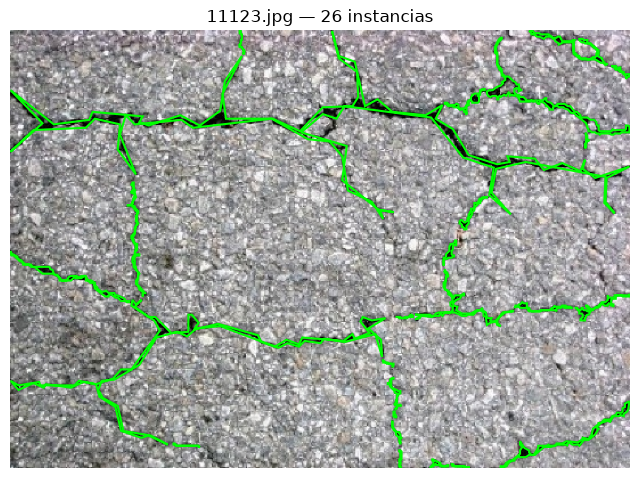

In [4]:
split = "train"
img_path = pd.OUT_ROOT / split / "images" / "11123.jpg"
lbl_path = pd.OUT_ROOT / split / "labels" / "11123.txt"
draw_yolo_seg_labels(img_path, lbl_path)

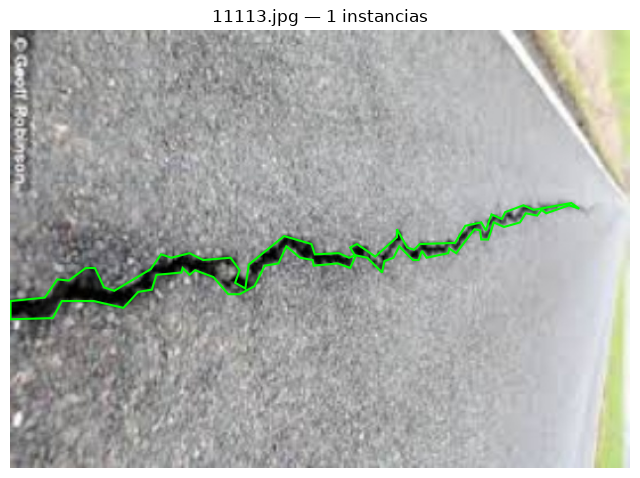

In [5]:
img_path = pd.OUT_ROOT / "train" / "images" / "11113.jpg"
lbl_path = pd.OUT_ROOT / "train" / "labels" / "11113.txt"
draw_yolo_seg_labels(img_path, lbl_path)